In [1]:

import pandas as pd
df = pd.read_csv("../data/cs-training.csv", index_col=0)

rename = {
 "SeriousDlqin2yrs":"default", "RevolvingUtilizationOfUnsecuredLines":"utilization",
 "age":"age", "NumberOfTime30-59DaysPastDueNotWorse":"late_30_59",
 "DebtRatio":"debt_ratio", "MonthlyIncome":"income",
 "NumberOfOpenCreditLinesAndLoans":"open_lines", "NumberOfTimes90DaysLate":"late_90",
 "NumberRealEstateLoansOrLines":"real_estate_loans",
 "NumberOfTime60-89DaysPastDueNotWorse":"late_60_89", "NumberOfDependents":"dependents"}
df = df.rename(columns=rename)

In [2]:
import sys; sys.path.append("../src")
from features import clean_and_engineer
df = df[df["age"] >= 18]
X = clean_and_engineer(df.drop(columns="default"))
y = df["default"]

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

In [4]:
y_test.mean()


np.float64(0.06683333333333333)

In [5]:
y_train.mean()

np.float64(0.06684222368519738)

In [6]:
from sklearn.model_selection import cross_validate
scoring = ["roc_auc","precision","recall","f1"]

def evaluate(model, name):
    res = cross_validate(model, X_train, y_train, cv=5, scoring=scoring, n_jobs=-1)
    return{"model": name, **{m: res[f"test_{m}"].mean().round(3) for m in scoring}}


In [7]:
from sklearn.dummy import DummyClassifier
results = [evaluate(DummyClassifier(strategy="most_frequent"), "Dummy")]

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

log_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scalar", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced",max_iter=1000))])
results.append(evaluate(log_reg, "Logistic Regression"))
pd.DataFrame(results)



,model,roc_auc,precision,recall,f1
0,Dummy,0.500,0.00,0.000,0.000
1,Logistic Regression,0.857,0.22,0.738,0.339


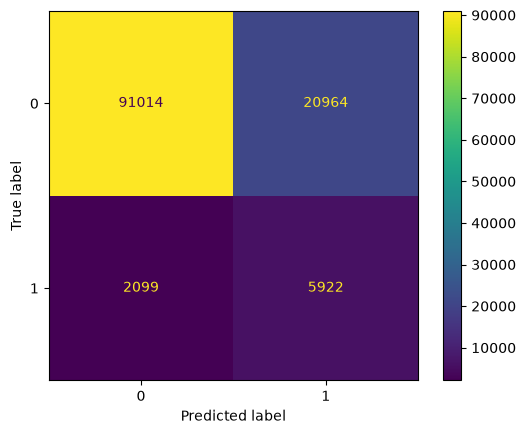

In [9]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
pred = cross_val_predict(log_reg, X_train, y_train, cv=5)
ConfusionMatrixDisplay(confusion_matrix(y_train,pred)).plot()

- **True Positive** : 91014 (Person is a defaulter and is predicted a defaulter)
- **False positive** : 20964 (Person isn't a defaulter and is predicted a defaulter)
- **False Negetive** : 2099 (Person is a defaulter and is predicted not a defaulter)
- **True Negetive** : 5922 (Person isn't a defaulter and is predicted not a defaulter)

**Precision**: TP/(TP+FP) = 91014/(91014+20964) = 0.81 (81%)
*Of everyone my model flagged as high risk, about 81% went to default, I actually captures many defaults, 4 in 5 flagged peoples are default*

**Recall**: TP/(TP+FN) = 91014/(91014+2099) = 0.97 (97%)  
*Of everyone who really defaulted, my model caught 97% of the in advance, only 3% slipped through as safe*

In [10]:
log_reg.fit(X_train, y_train)

coefs = pd.DataFrame({
    "features": X_train.columns,
    "coefficients": log_reg["model"].coef_[0]
}).sort_values("coefficients", ascending=False)

print(coefs)

             features  coefficients
0         utilization      0.706716
13        any_90_late      0.325101
2          late_30_59      0.248530
8          late_60_89      0.242837
12         total_late      0.231023
5          open_lines      0.183380
7   real_estate_loans      0.141490
10   placeholder_code      0.107974
15  income_per_person      0.105767
11     income_missing      0.073991
14       monthly_debt      0.050896
9          dependents      0.041021
16         over_limit      0.033397
6             late_90      0.000550
17         log_income     -0.027438
3          debt_ratio     -0.154482
1                 age     -0.287672
4              income     -0.290573


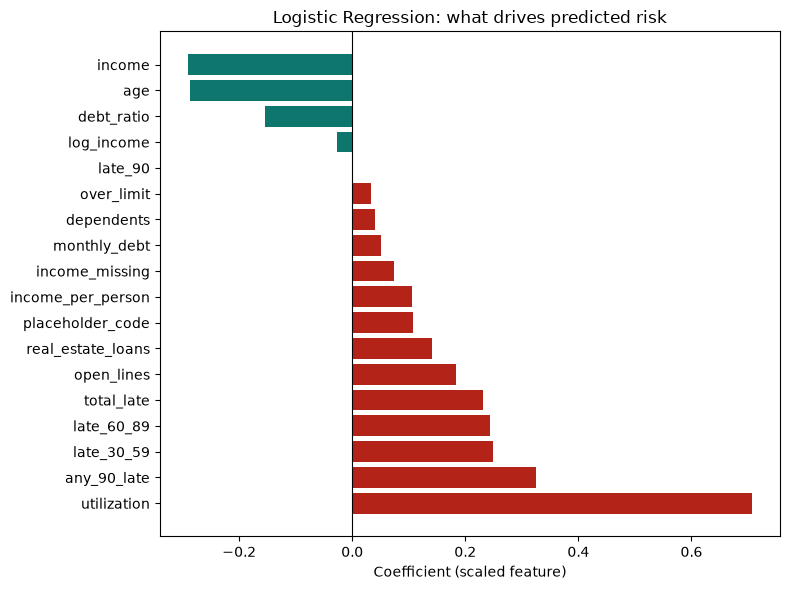

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.barh(coefs["features"], coefs["coefficients"], color=coefs["coefficients"].apply(lambda c: "#b42318" if c > 0 else "#0f766e"))
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient (scaled feature)")
plt.title("Logistic Regression: what drives predicted risk")
plt.tight_layout()
plt.savefig("../assets/logreg_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

- **Risk Increasing Variables** --> Utilization, any_90_late
- **Risk Decreasing Variables** --> income, age, debt_ratio

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
tree_pre = lambda m: Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", m)])
for d in [3,5,8,12, None]:
    m = tree_pre(DecisionTreeClassifier(max_depth=d, class_weight="balanced", random_state = 42))
    print(d, evaluate(m, f"Tree depth={d}"))

3 {'model': 'Tree depth=3', 'roc_auc': np.float64(0.832), 'precision': np.float64(0.199), 'recall': np.float64(0.746), 'f1': np.float64(0.308)}
5 {'model': 'Tree depth=5', 'roc_auc': np.float64(0.849), 'precision': np.float64(0.197), 'recall': np.float64(0.774), 'f1': np.float64(0.313)}
8 {'model': 'Tree depth=8', 'roc_auc': np.float64(0.836), 'precision': np.float64(0.2), 'recall': np.float64(0.754), 'f1': np.float64(0.316)}
12 {'model': 'Tree depth=12', 'roc_auc': np.float64(0.761), 'precision': np.float64(0.201), 'recall': np.float64(0.682), 'f1': np.float64(0.31)}
None {'model': 'Tree depth=None', 'roc_auc': np.float64(0.604), 'precision': np.float64(0.264), 'recall': np.float64(0.26), 'f1': np.float64(0.262)}


In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate
import matplotlib.pyplot as plt

tree_pre = lambda m: Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", m)])

depth_rows = []
for d in [2, 3, 4, 5, 6, 8, 10, 12, 20, None]:
    m = tree_pre(DecisionTreeClassifier(max_depth=d, class_weight="balanced", random_state=42))
    res = cross_validate(m, X_train, y_train, cv=5, scoring="roc_auc",
                         return_train_score=True, n_jobs=-1)
    depth_rows.append({"depth": d,
                       "train_auc": res["train_score"].mean(),
                       "cv_auc": res["test_score"].mean()})

depth_df = pd.DataFrame(depth_rows).round(3)
print(depth_df)

   depth  train_auc  cv_auc
0    2.0      0.819   0.819
1    3.0      0.836   0.832
2    4.0      0.850   0.846
3    5.0      0.857   0.849
4    6.0      0.862   0.847
5    8.0      0.877   0.836
6   10.0      0.897   0.804
7   12.0      0.922   0.761
8   20.0      0.987   0.664
9    NaN      1.000   0.604


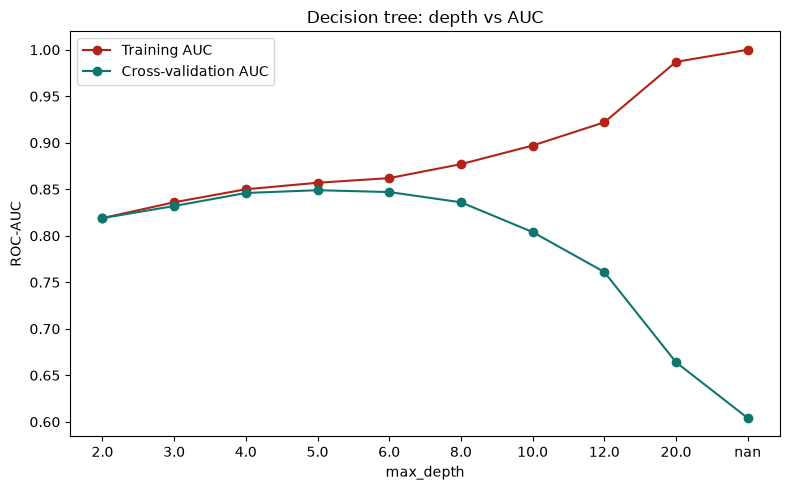

In [14]:
labels = [str(d) for d in depth_df["depth"]]      # "None" means no depth limit
plt.figure(figsize=(8, 5))
plt.plot(labels, depth_df["train_auc"], marker="o", label="Training AUC", color="#b42318")
plt.plot(labels, depth_df["cv_auc"], marker="o", label="Cross-validation AUC", color="#0f766e")
plt.xlabel("max_depth")
plt.ylabel("ROC-AUC")
plt.title("Decision tree: depth vs AUC")
plt.legend()
plt.tight_layout()
plt.savefig("../assets/tree_depth_vs_auc.png", dpi=150, bbox_inches="tight")
plt.show()

cross validation auc started falling at depth > 5, as model became overfitted by make more general classifications at nan(infinite depth) the model became extremely general to training data that it failed in a large margine at testing data it was given

In [15]:
best_d = depth_df.loc[depth_df["cv_auc"].idxmax(), "depth"]
best_d = None if pd.isna(best_d) else int(best_d)   # pandas turns None into NaN

best_tree = tree_pre(DecisionTreeClassifier(max_depth=best_d, class_weight="balanced", random_state=42))
results.append(evaluate(best_tree, f"Decision Tree (depth={best_d})"))
pd.DataFrame(results)

,model,roc_auc,precision,recall,f1
0,Dummy,0.500,0.000,0.000,0.000
1,Logistic Regression,0.857,0.220,0.738,0.339
2,Decision Tree (depth=5),0.849,0.197,0.774,0.313


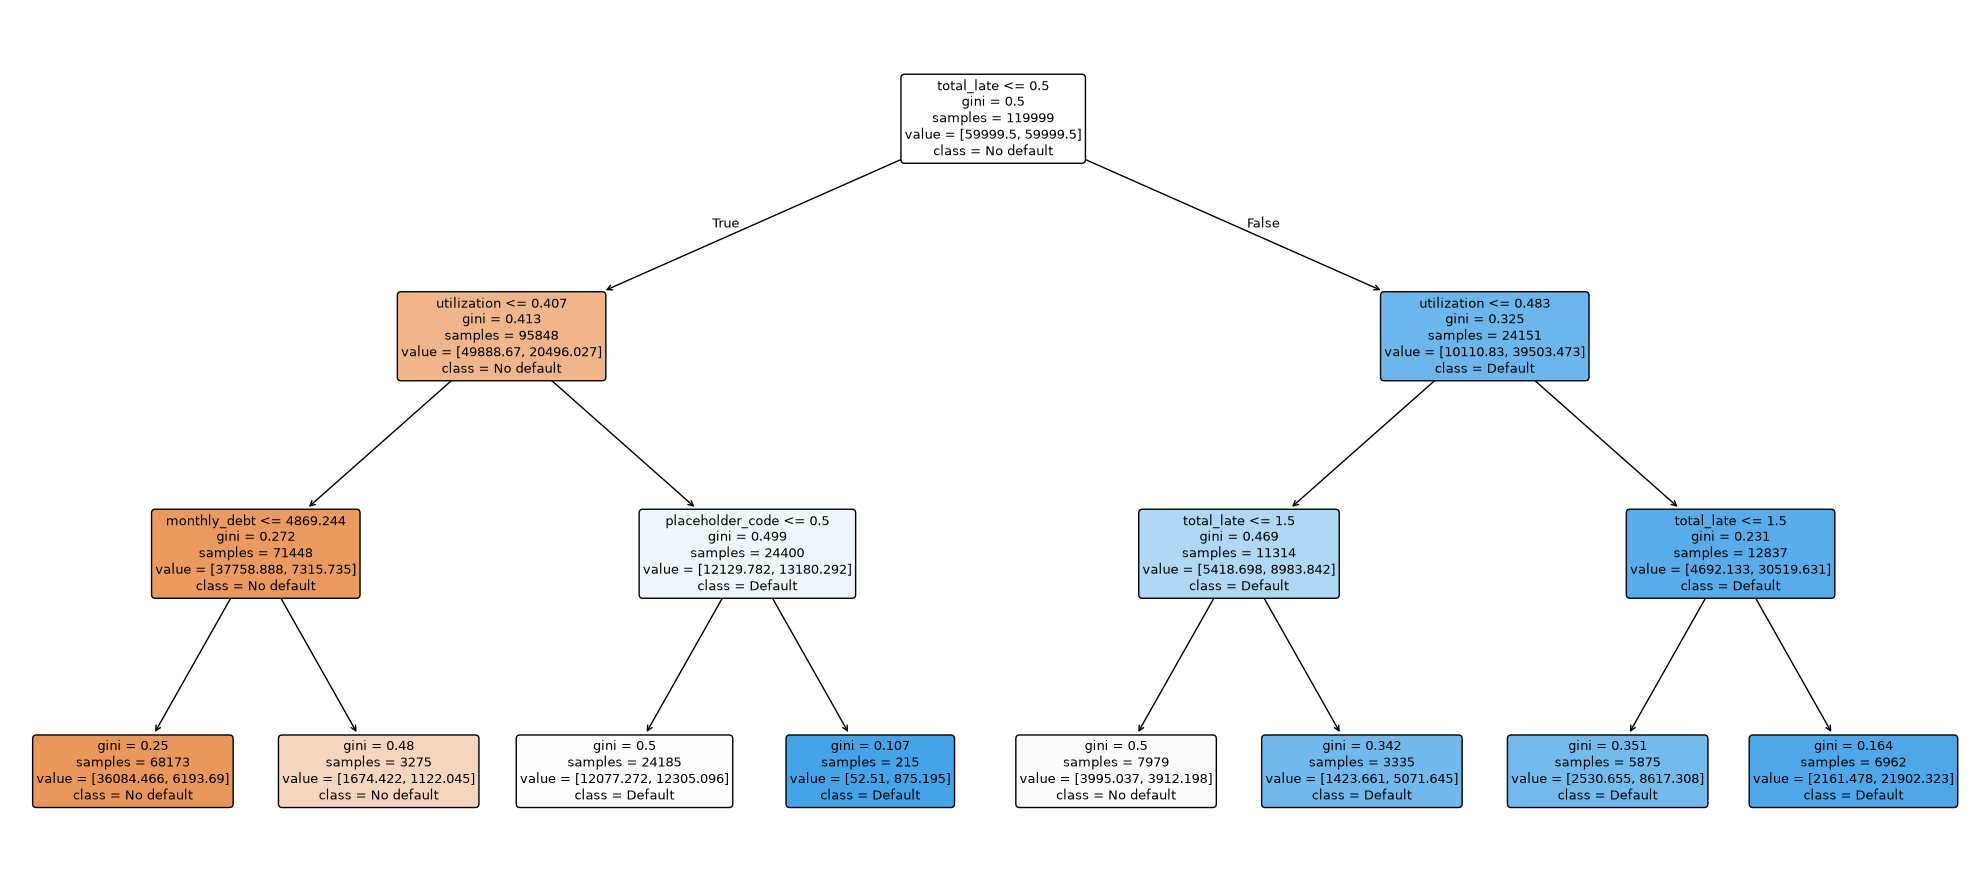

In [16]:
from sklearn.tree import plot_tree

X_imp = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X_train),
                     columns=X_train.columns)

small_tree = DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=42)
small_tree.fit(X_imp, y_train)

plt.figure(figsize=(20, 9))
plot_tree(small_tree, feature_names=list(X_train.columns),
          class_names=["No default", "Default"],
          filled=True, rounded=True, fontsize=9)
plt.tight_layout()
plt.savefig("../assets/decision_tree.png", dpi=200, bbox_inches="tight")
plt.show()

People with several late payments and high utilization end up in the darkest 'Default' leaf." That shows you can interpret a model

In [17]:
from sklearn.ensemble import RandomForestClassifier
rf = tree_pre(RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=20,
      class_weight="balanced_subsample", n_jobs=-1, random_state=42))
results.append(evaluate(rf, "Random Forest"))

In [18]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

rf_kwargs = dict(n_estimators=100, max_depth=10, min_samples_leaf=20, random_state=42)

candidates = {
    "RF: no imbalance handling": ImbPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(**rf_kwargs)),
    ]),
    "RF: class_weight": ImbPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(class_weight="balanced_subsample", **rf_kwargs)),
    ]),
    "RF: SMOTE": ImbPipeline([
        ("imputer", SimpleImputer(strategy="median")),   # SMOTE cannot handle NaN, so impute first
        ("smote", SMOTE(random_state=42)),
        ("model", RandomForestClassifier(**rf_kwargs)),  # no class_weight here
    ]),
}

imb_results = [evaluate(model, name) for name, model in candidates.items()]
imb_df = pd.DataFrame(imb_results)
print(imb_df)

                       model  roc_auc  precision  recall     f1
0  RF: no imbalance handling    0.863      0.615   0.172  0.268
1           RF: class_weight    0.862      0.234   0.726  0.354
2                  RF: SMOTE    0.857      0.414   0.425  0.419


In [19]:
results.append(imb_df.iloc[1].to_dict())

All three approaches reached roc_auc 86%, with SMOTE is slightly lowest about 85.7%, without imbalance handling the recall was about 17% at the default threshold. Class weight raised recall up to 73% at the cost of lowering precision and reaching 23.4%, and SMOTE landed in between. Since SMOTE brought no AUC gain and adds training time and complexity, I kept class_weight and will tune the decision threshold to set the precision-recall balance.

In [20]:
from xgboost import XGBClassifier

# Computing the ratio from  data instead of hard-coding 14
spw = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(spw, 1))

xgb = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                            scale_pos_weight=spw, eval_metric="auc",
                            n_jobs=-1, random_state=42))])

results.append(evaluate(xgb, "XGBoost"))
pd.DataFrame(results)

scale_pos_weight: 14.0


,model,roc_auc,precision,recall,f1
0,Dummy,0.500,0.000,0.000,0.000
1,Logistic Regression,0.857,0.220,0.738,0.339
2,Decision Tree (depth=5),0.849,0.197,0.774,0.313
3,Random Forest,0.862,0.235,0.729,0.356
4,RF: class_weight,0.862,0.234,0.726,0.354
5,XGBoost,0.864,0.216,0.771,0.337


XGBoost gave no meaningful gain over random forest

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
params = {"model__n_estimators": [200, 300], "model__max_depth": [6, 8, 12],
          "model__min_samples_leaf": [5, 20, 50], "model__max_features": ["sqrt", 0.5]}
search = RandomizedSearchCV(rf, params, n_iter=12, cv=3, scoring="roc_auc",
                            n_jobs=-1, random_state=42)
search.fit(X_train, y_train)
best = search.best_estimator_

In [22]:
# Print the best hyperparameter combination found
print("Winning Parameters:")
print(search.best_params_)

# Print the best ROC AUC score achieved during the search
print(f"\nBest Cross-Validation ROC AUC: {search.best_score_:.4f}")


Winning Parameters:
{'model__n_estimators': 300, 'model__min_samples_leaf': 50, 'model__max_features': 'sqrt', 'model__max_depth': 8}

Best Cross-Validation ROC AUC: 0.8618


In [27]:
from sklearn.metrics import precision_recall_curve
import numpy as np
proba = cross_val_predict(best, X_train, y_train, cv=5, method="predict_proba")[:,1]
prec,rec,thr = precision_recall_curve(y_train, proba)
ok = rec[:-1]>= 0.70
threshold = thr[ok][np.argmax(prec[:-1][ok])]


In [28]:

from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
best.fit(X_train, y_train)
test_proba = best.predict_proba(X_test)[:, 1]
print(roc_auc_score(y_test, test_proba))
print(classification_report(y_test, test_proba >= threshold))


0.8664621888750174
              precision    recall  f1-score   support

           0       0.98      0.86      0.91     27995
           1       0.26      0.71      0.38      2005

    accuracy                           0.85     30000
   macro avg       0.62      0.78      0.65     30000
weighted avg       0.93      0.85      0.88     30000



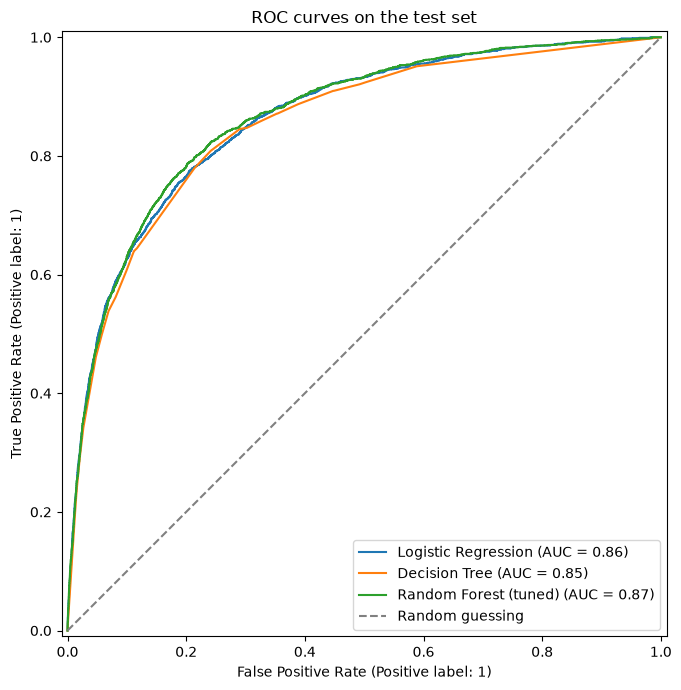

In [29]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
models_to_plot = {
    "Logistic Regression": log_reg,
    "Decision Tree": best_tree,
    "Random Forest (tuned)": best,
}

fig, ax = plt.subplots(figsize=(7, 7))
for name, model in models_to_plot.items():
    model.fit(X_train, y_train)   # make sure each is fitted on the full training set
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random guessing")
ax.set_title("ROC curves on the test set")
ax.legend()
plt.tight_layout()
plt.savefig("../assets/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

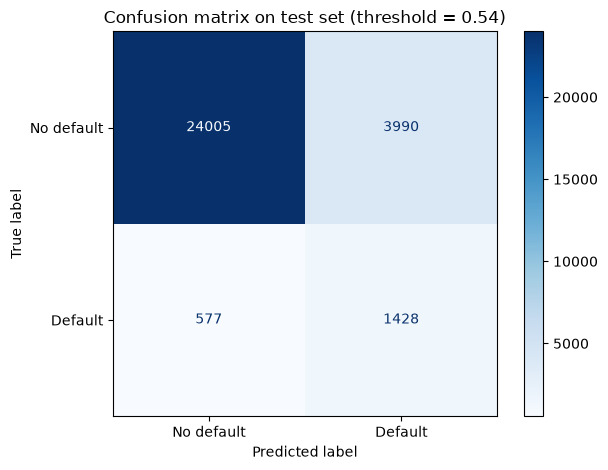

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

test_pred = (test_proba >= threshold).astype(int)
cm = confusion_matrix(y_test, test_pred)

ConfusionMatrixDisplay(cm, display_labels=["No default", "Default"]).plot(cmap="Blues")
plt.title(f"Confusion matrix on test set (threshold = {threshold:.2f})")
plt.tight_layout()
plt.savefig("../assets/confusion_matrix_test.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

test_auc = roc_auc_score(y_test, test_proba)
print(f"Test ROC-AUC: {test_auc:.3f}")

if test_auc < 0.75 or test_auc > 0.95:
    print("⚠️ Outside the expected 0.75-0.95 range — check for a bug or data leakage before continuing.")
else:
    print("✅ In the expected range for this dataset.")

Test ROC-AUC: 0.866
✅ In the expected range for this dataset.


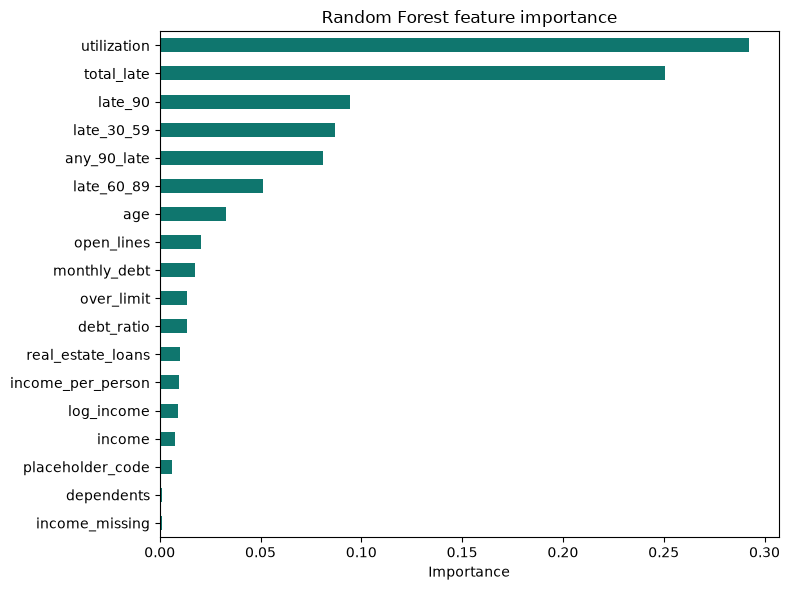

In [32]:
importances = pd.Series(best["model"].feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=True)   # ascending so biggest bar is on top in barh

plt.figure(figsize=(8, 6))
importances.plot(kind="barh", color="#0f766e")
plt.title("Random Forest feature importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../assets/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

The threshold is set to be 70% recall and the precision according to it ensuring 70% defaulters are caught and non defaulters are flagged lesser 

Utilization, total_late, late_90 are top three features

In [ ]:
import joblib, json
joblib.dump(best, "../models/credit_model.joblib")
json.dump({"threshold": float(threshold)}, open("../models/config.json", "w"))

In [35]:
idx = np.where(ok)[0][np.argmax(prec[:-1][ok])]
print("Precision:", prec[idx], "Recall:", rec[idx])

Precision: 0.2552843311059594 Recall: 0.700162074554295


In [36]:
for r_min in [0.60, 0.65, 0.70, 0.75, 0.80]:
    mask = rec[:-1] >= r_min
    i = np.argmax(prec[:-1][mask])
    t = thr[mask][i]
    print(f"recall>={r_min}: threshold={t:.3f}, precision={prec[:-1][mask][i]:.3f}, recall={rec[:-1][mask][i]:.3f}")

recall>=0.6: threshold=0.642, precision=0.317, recall=0.600
recall>=0.65: threshold=0.580, precision=0.284, recall=0.650
recall>=0.7: threshold=0.541, precision=0.255, recall=0.700
recall>=0.75: threshold=0.501, precision=0.222, recall=0.750
recall>=0.8: threshold=0.459, precision=0.196, recall=0.800


At the chosen threshold of 0.54, the model catches 70% of borrowers who go on to default, at the cost of a 74.5% false-positive rate among flagged cases. This trade-off was chosen because, for a lender, failing to catch a defaulter is costlier than extra scrutiny on a safe borrower.

In [37]:
import os
os.makedirs("../assets", exist_ok=True)
pd.DataFrame({"y_true": y_test.values, "proba": test_proba}).to_csv("../models/test_scores.csv", index=False)
pd.DataFrame(results).to_csv("../models/results.csv", index=False)